In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
file_path = "../data/processed/cleaned_fraud_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6362620, 9)


In [3]:
x = df.drop(columns=["isFraud"])
y = df["isFraud"]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (6362620, 8)
y shape: (6362620,)


In [4]:
categorical_features = ["type"]

numerical_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud"
]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [6]:
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (5090096, 8)
Testing shape: (1272524, 8)


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [8]:
x_train_processed = preprocessor.fit_transform(x_train)

In [9]:
x_test_processed = preprocessor.transform(x_test)

In [10]:
print("Processed training shape:", x_train_processed.shape)
print("Processed testing shape:", x_test_processed.shape)

Processed training shape: (5090096, 12)
Processed testing shape: (1272524, 12)


In [11]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [12]:
model.fit(
    x_train_processed,
    y_train
)

print("Baseline Logistic Regression trained successfully!")

Baseline Logistic Regression trained successfully!


In [13]:
y_pred = model.predict(x_test_processed)

y_proba = model.predict_proba(x_test_processed)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [14]:
print("Actual fraud transactions:", y_test.sum())
print("Predicted fraud transactions:", y_pred.sum())

Actual fraud transactions: 1643
Predicted fraud transactions: 729


In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("Baseline Logistic Regression")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Baseline Logistic Regression
-----------------------------------
Accuracy : 0.9992
Precision: 0.9136
Recall   : 0.4054
F1-Score : 0.5616
ROC-AUC  : 0.9738


In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
       Fraud       0.91      0.41      0.56      1643

    accuracy                           1.00   1272524
   macro avg       0.96      0.70      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1270818      63]
 [    977     666]]


In [18]:
import seaborn as sns

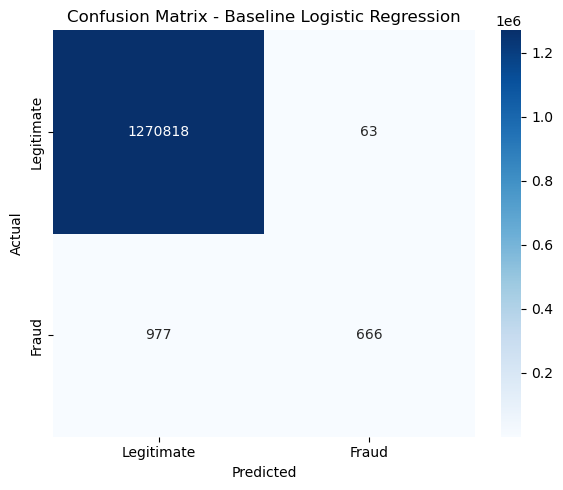

In [19]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [21]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nPercentages:")
print(y_train.value_counts(normalize=True) * 100)

Before SMOTE:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Percentages:
isFraud
0    99.870926
1     0.129074
Name: proportion, dtype: float64


In [22]:
smote = SMOTE(
    sampling_strategy=0.01,
    random_state=42,
    k_neighbors=5
)

In [23]:
x_train_smote, y_train_smote = smote.fit_resample(
    x_train_processed,
    y_train
)

In [24]:
print("After SMOTE:")
print(y_train_smote.value_counts())

print("\nPercentages:")
print(
    y_train_smote.value_counts(normalize=True) * 100
)

After SMOTE:
isFraud
0    5083526
1      50835
Name: count, dtype: int64

Percentages:
isFraud
0    99.009906
1     0.990094
Name: proportion, dtype: float64


In [25]:
print("Test set shape:", x_test_processed.shape)

print("\nTest target distribution:")
print(y_test.value_counts())

Test set shape: (1272524, 12)

Test target distribution:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


In [26]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [27]:
smote_model.fit(
    x_train_smote,
    y_train_smote
)

print("Logistic Regression with SMOTE trained successfully!")

Logistic Regression with SMOTE trained successfully!


In [28]:
y_pred_smote = smote_model.predict(
    x_test_processed
)

y_proba_smote = smote_model.predict_proba(
    x_test_processed
)[:, 1]

print("SMOTE predictions generated successfully!")

SMOTE predictions generated successfully!


In [29]:
accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

precision_smote = precision_score(
    y_test,
    y_pred_smote,
    zero_division=0
)

recall_smote = recall_score(
    y_test,
    y_pred_smote,
    zero_division=0
)

f1_smote = f1_score(
    y_test,
    y_pred_smote,
    zero_division=0
)

roc_auc_smote = roc_auc_score(
    y_test,
    y_proba_smote
)

print("Logistic Regression + SMOTE")
print("-" * 35)
print(f"Accuracy : {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall   : {recall_smote:.4f}")
print(f"F1-Score : {f1_smote:.4f}")
print(f"ROC-AUC  : {roc_auc_smote:.4f}")

Logistic Regression + SMOTE
-----------------------------------
Accuracy : 0.9991
Precision: 0.6744
Recall   : 0.5989
F1-Score : 0.6344
ROC-AUC  : 0.9923


In [30]:
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
       Fraud       0.67      0.60      0.63      1643

    accuracy                           1.00   1272524
   macro avg       0.84      0.80      0.82   1272524
weighted avg       1.00      1.00      1.00   1272524



In [31]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print("SMOTE Confusion Matrix:")
print(cm_smote)

SMOTE Confusion Matrix:
[[1270406     475]
 [    659     984]]


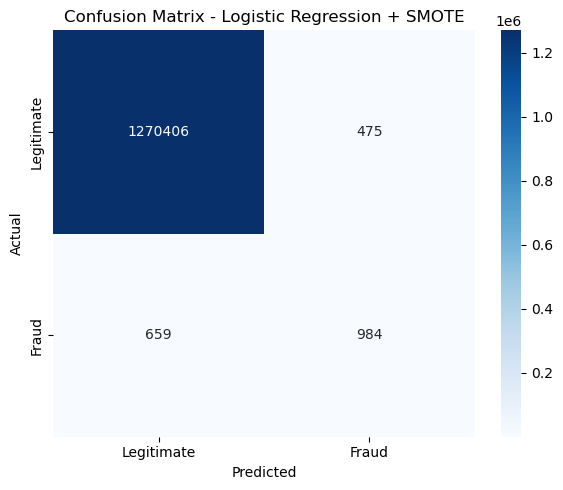

In [32]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Logistic Regression + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [33]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + SMOTE"
    ],
    "Precision": [
        precision,
        precision_smote
    ],
    "Recall": [
        recall,
        recall_smote
    ],
    "F1-Score": [
        f1,
        f1_smote
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_smote
    ]
})

comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.913580,0.405356,0.561551,0.973819
1,Logistic Regression + SMOTE,0.674435,0.598904,0.634429,0.992333


## Baseline vs SMOTE — Conclusion

SMOTE improved the Logistic Regression model's ability to detect fraudulent
transactions.

Recall increased from 40.54% to 59.89%, while F1-score increased from 56.16%
to 63.44%. ROC-AUC also improved from 97.38% to 99.23%.

However, Precision decreased from 91.36% to 67.44%, indicating that the SMOTE
model generates more false-positive fraud alerts.

For this project, Logistic Regression with SMOTE is selected as the preferred
model because fraud detection places significant importance on identifying
more actual fraudulent transactions, and the SMOTE model provides a better
balance between Precision and Recall based on the F1-score.

In [35]:
iso_train = x_train.copy()

iso_train["isFraud"] = y_train

iso_sample = iso_train.sample(
    n=100000,
    random_state=42
)

print(iso_sample.shape)

(100000, 9)


In [40]:
iso_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud"
]

In [38]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

In [41]:
iso_model.fit(
    iso_sample[iso_features]
)

print("Isolation Forest trained successfully!")

Isolation Forest trained successfully!


In [42]:
iso_test = x_test.copy()

iso_test["isFraud"] = y_test

iso_test_sample = iso_test.sample(
    n=100000,
    random_state=42
)

In [43]:
iso_pred = iso_model.predict(
    iso_test_sample[iso_features]
)

In [44]:
iso_pred_binary = np.where(
    iso_pred == -1,
    1,
    0
)

In [45]:
iso_precision = precision_score(
    iso_test_sample["isFraud"],
    iso_pred_binary,
    zero_division=0
)

iso_recall = recall_score(
    iso_test_sample["isFraud"],
    iso_pred_binary,
    zero_division=0
)

iso_f1 = f1_score(
    iso_test_sample["isFraud"],
    iso_pred_binary,
    zero_division=0
)

print("Isolation Forest")
print("-" * 30)
print(f"Precision: {iso_precision:.4f}")
print(f"Recall   : {iso_recall:.4f}")
print(f"F1-Score : {iso_f1:.4f}")

Isolation Forest
------------------------------
Precision: 0.0141
Recall   : 0.1364
F1-Score : 0.0256


## Final Model Selection

Logistic Regression with SMOTE was selected as the final model.

It achieved 67.44% Precision, 59.89% Recall, 63.44% F1-score, and 99.23% ROC-AUC.

Compared with the baseline Logistic Regression model, SMOTE improved Recall,
F1-score, and ROC-AUC, although Precision decreased.

The SMOTE model was selected because detecting more fraudulent transactions
is a key priority for this fraud detection system.

In [46]:
import joblib

In [47]:
joblib.dump(
    smote_model,
    "../models/fraud_detection_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [48]:
joblib.dump(
    preprocessor,
    "../models/fraud_detection_preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [49]:
import os

print(os.path.exists("../models/fraud_detection_model.pkl"))
print(os.path.exists("../models/fraud_detection_preprocessor.pkl"))

True
True


In [50]:
print("Final Model: Logistic Regression + SMOTE")
print("-" * 40)

print(f"Precision : {precision_smote:.4f}")
print(f"Recall    : {recall_smote:.4f}")
print(f"F1-Score  : {f1_smote:.4f}")
print(f"ROC-AUC   : {roc_auc_smote:.4f}")

Final Model: Logistic Regression + SMOTE
----------------------------------------
Precision : 0.6744
Recall    : 0.5989
F1-Score  : 0.6344
ROC-AUC   : 0.9923


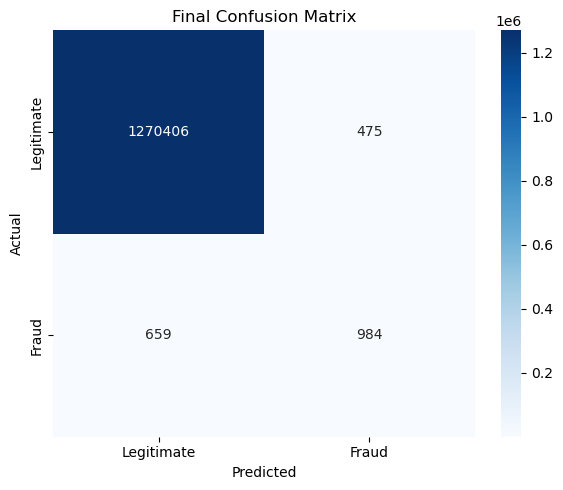

In [51]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(
    "../images/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [53]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_smote
)

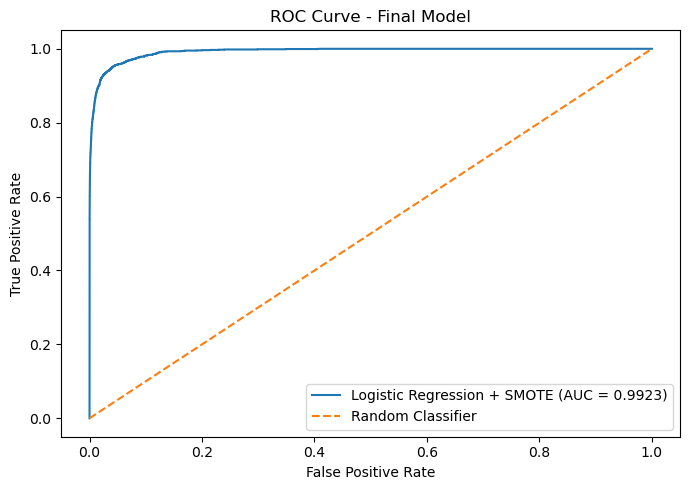

In [54]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression + SMOTE (AUC = {roc_auc_smote:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()

plt.tight_layout()
plt.savefig(
    "../images/final_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()